In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from typing import TypedDict, Literal, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator
import os

In [15]:
from langgraph.checkpoint.memory import MemorySaver

Guarda memoria en RAM

In [16]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
     messages: Annotated[list[BaseMessage], add_messages]

In [17]:
load_dotenv()

True

In [18]:
llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    base_url="https://api.groq.com/openai/v1",
    api_key=os.getenv("GROQ_API_KEY")
)

In [19]:
def chat_node(state: ChatState):

    messages = state["messages"]

    response = llm.invoke(messages)

    return {"messages": [response]}

In [29]:
checkpointer = MemorySaver()

In [20]:
graph = StateGraph(ChatState)

In [21]:
graph.add_node("chat_node", chat_node)

In [22]:
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

In [30]:
chatbot = graph.compile(checkpointer=checkpointer)

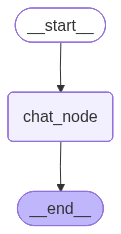

In [31]:
chatbot

In [25]:
initial_state = {
    "messages": [HumanMessage(content="Hello, how are you?")]
}

chatbot.invoke(initial_state)

{'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='d7ca0879-7c12-4fef-bd65-a0972723d4fc'),
  AIMessage(content='Hello! I’m doing great, thanks for asking. How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 77, 'total_tokens': 117, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 13, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.14676962, 'prompt_time': 0.00313866, 'completion_time': 0.083031407, 'total_time': 0.086170067}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_caa2017b29', 'id': 'chatcmpl-ec7cb389-d559-46a5-ab0c-abe85cfe1fcb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cd84d-4a08-7f51-bfd4-1af49dfa2bc6-0', tool_calls=[], invalid_tool_calls=[], usage

In [26]:
initial_state = {
    "messages": [HumanMessage(content="Hello, how are you?")]
}

chatbot.invoke(initial_state)["messages"][-1].content

"Hello! I'm doing well, thank you for asking. How can I help you today?"

In [34]:
thread_id = "1"

while True:
    user_input = input("You: ")

    print(f"User: {user_input}")

    if user_input.strip().lower() in ["exit", "quit", "bye"]:
        print("Exiting chat.")
        break

    config = {'configurable': {'thread_id': thread_id}}

    response = chatbot.invoke({"messages": [HumanMessage(content=user_input)]}, config=config)["messages"][-1].content

    print(f"AI: {response}")

User: hi
AI: Hey there! 👋 How’s it going? Anything fun or interesting you’d like to chat about today?
User: my name is ...
AI: Got it! What would you like me to call you?
User: 
AI: It looks like the name didn’t come through. Could you let me know what you’d like to be called? 😊


KeyboardInterrupt: Interrupted by user

In [33]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi my name is Ulises', additional_kwargs={}, response_metadata={}, id='a7204d36-2469-4571-ad41-332502b2dc20'), AIMessage(content='Hello Ulises! Nice to meet you. How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 77, 'total_tokens': 110, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 8, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.148468127, 'prompt_time': 0.004392664, 'completion_time': 0.072273163, 'total_time': 0.076665827}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_27107d8ba0', 'id': 'chatcmpl-8ff4116a-4f67-407e-9d3f-b65da90405f9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cd851-37c2-77f3-854d-37d0c5a34fe9-0', tool_calls=[], invalid_tool_calls=[